### CSC1204 Machine Learning – Project-Based Examination
#### Easter 2026 Semester

**Group:** Three

- MWAZIA MARK S24B23/058
- KISAKYE MARIA SENGENDO S24B38/033
- ASASIRA MORRIS. A S24B23/116
- ODONG JEFERSON CLINTON S24B23/043
- MWONGE ANDREA S24B23/070
- MUTEBI MARK JONAH S24B23/105
- MUKIDI ANDREW M24B23/035
- KAYONGO ALOYSIUS S24B23/016
- BABIRYE JOY LENAH M24B38/018


**Program:** BSc Computer Science/ Data Science – Year 2  
**Course:** CSC1204 Machine Learning  
**Date:** April 2026

---

### Project Title: Predicting Employee Attrition Using A Supervised learning Model

This notebook covers all five sections of the project exam:
- **Section A** – Problem Definition & Dataset Acquisition
- **Section B** – Exploratory Data Analysis (EDA)
- **Section C** – Model Building & Training
- **Section D** – Model Evaluation & Comparison
- **Section E** – Summary Insights (supporting the written report)

### Section A
**a) Problem Statement**

- Employee attrition is a critical challenge faced by organizations since the loss of skilled employees leads to increased recruitment costs, reduced productivity and disruption of business operations. High attrition rates can negatively impact team performance, knowledge retention within the institution and overall organizational stability. This makes understanding and predicting employee attrition is essential for effective human resource management.

- This project aims to develop a supervised machine learning model to classify whether an employee is likely to leave the organization based on various factors such as age, job role, income, job satisfaction, work-life balance and years at the company or not. By using historical employee data, the model can identify patterns and key drivers associated with employee turnover. The target variable is Attrition and it is binary: **1 (Yes)** or **0 (No)**. 

- The primary stakeholders in this problem include human resource (HR) managers, organizational leaders and decision makers who are responsible for employee retention strategies. A reliable prediction model can support these stakeholders in making data-driven decisions, such as identifying at-risk employees, improving workplace conditions and designing targeted retention programs.


The main objectives of this project are:

- To analyze employee data and identify key factors influencing attrition.
- To build and train machine learning models that can accurately classify employee attrition.
- To evaluate and compare the performance of different models using appropriate classification metrics such as accuracy, precision, recall and F1-score.
- To provide actionable insights that can help organizations reduce employee turnover and improve retention strategies.

**b) Dataset Acquisition**

The dataset used in this project is the IBM HR Analytics Employee Attrition Dataset, which is publicly available on the Kaggle platform. This dataset contains detailed information about employees, including demographic, job-related and performance-related attributes, making it suitable for predicting employee attrition.

The dataset consists of approximately 1,470 records and over 30 features, thereby meeting the minimum requirement of at least 200 records and 5 features as specified in the project guidelines. It includes both numerical and categorical variables such as age, monthly income, job role, job satisfaction and work-life balance.

The target variable in this dataset is Attrition, which indicates whether an employee has left the organization (Yes) or not (No). This makes the dataset appropriate for a supervised classification task.

The dataset was obtained from the following source:

IBM HR Analytics Employee Attrition Dataset, available at:
https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

**c) Data Description**

In [45]:
!pip install pandas

In [46]:
!pip install numpy matplotlib seaborn sklearn 

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [48]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")

In [49]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


- The dataset was successfully loaded using Pandas. The first 10 rows are displayed above to provide an overview of the structure and contents of the dataset.

In [50]:
df.shape

(1470, 35)

- The dataset contains 1470 rows and 35 columns, indicating sufficient data for analysis and modeling.

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [52]:
cat_data=df.select_dtypes(include='object')
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


- The dataset consists of a mix of numerical and categorical variables. Numerical features include variables such as Age, MonthlyIncome, and YearsAtCompany, while categorical features include JobRole, Attrition, and OverTime.

Data Dictionary
| Column Name        | Description                                                               |
| ------------------ | ------------------------------------------------------------------------- |
| Age                | Age of the employee (in years)                                            |
| Attrition          | Target variable indicating whether the employee left the company (Yes/No) |
| BusinessTravel     | Frequency of business travel (e.g., Travel_Rarely, Travel_Frequently)     |
| Department         | Department in which the employee works (e.g., Sales, HR, R&D)             |
| DistanceFromHome   | Distance between employee’s home and workplace                            |
| Education          | Education level (1 = Below College, 5 = Doctor)                           |
| EducationField     | Field of education (e.g., Life Sciences, Medical, Marketing)              |
| Gender             | Gender of the employee                                                    |
| JobRole            | Job title/role of the employee                                            |
| JobSatisfaction    | Job satisfaction level (1 = Low, 4 = Very High)                           |
| MaritalStatus      | Marital status (Single, Married, Divorced)                                |
| MonthlyIncome      | Monthly salary earned by the employee                                     |
| OverTime           | Whether the employee works overtime (Yes/No)                              |
| PercentSalaryHike  | Percentage increase in salary                                             |
| PerformanceRating  | Performance rating of the employee (1–4)                                  |
| TotalWorkingYears  | Total years of professional work experience                               |
| YearsAtCompany     | Number of years the employee has worked at the company                    |
| YearsInCurrentRole | Years spent in the current role                                           |
| WorkLifeBalance    | Work-life balance rating (1 = Bad, 4 = Excellent)                         |


In [53]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

- The dataset does not contain any missing values, indicating that it is clean and ready for further analysis.

### Section B

**a) Summary Statistics & Data Cleaning**

In [54]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


We did not handle any missing values because the data does not have missing values

In [55]:
df_clean = df.copy()

In [56]:
df_clean.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [57]:
cont_data=df_clean.select_dtypes(exclude='object')
cont_data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


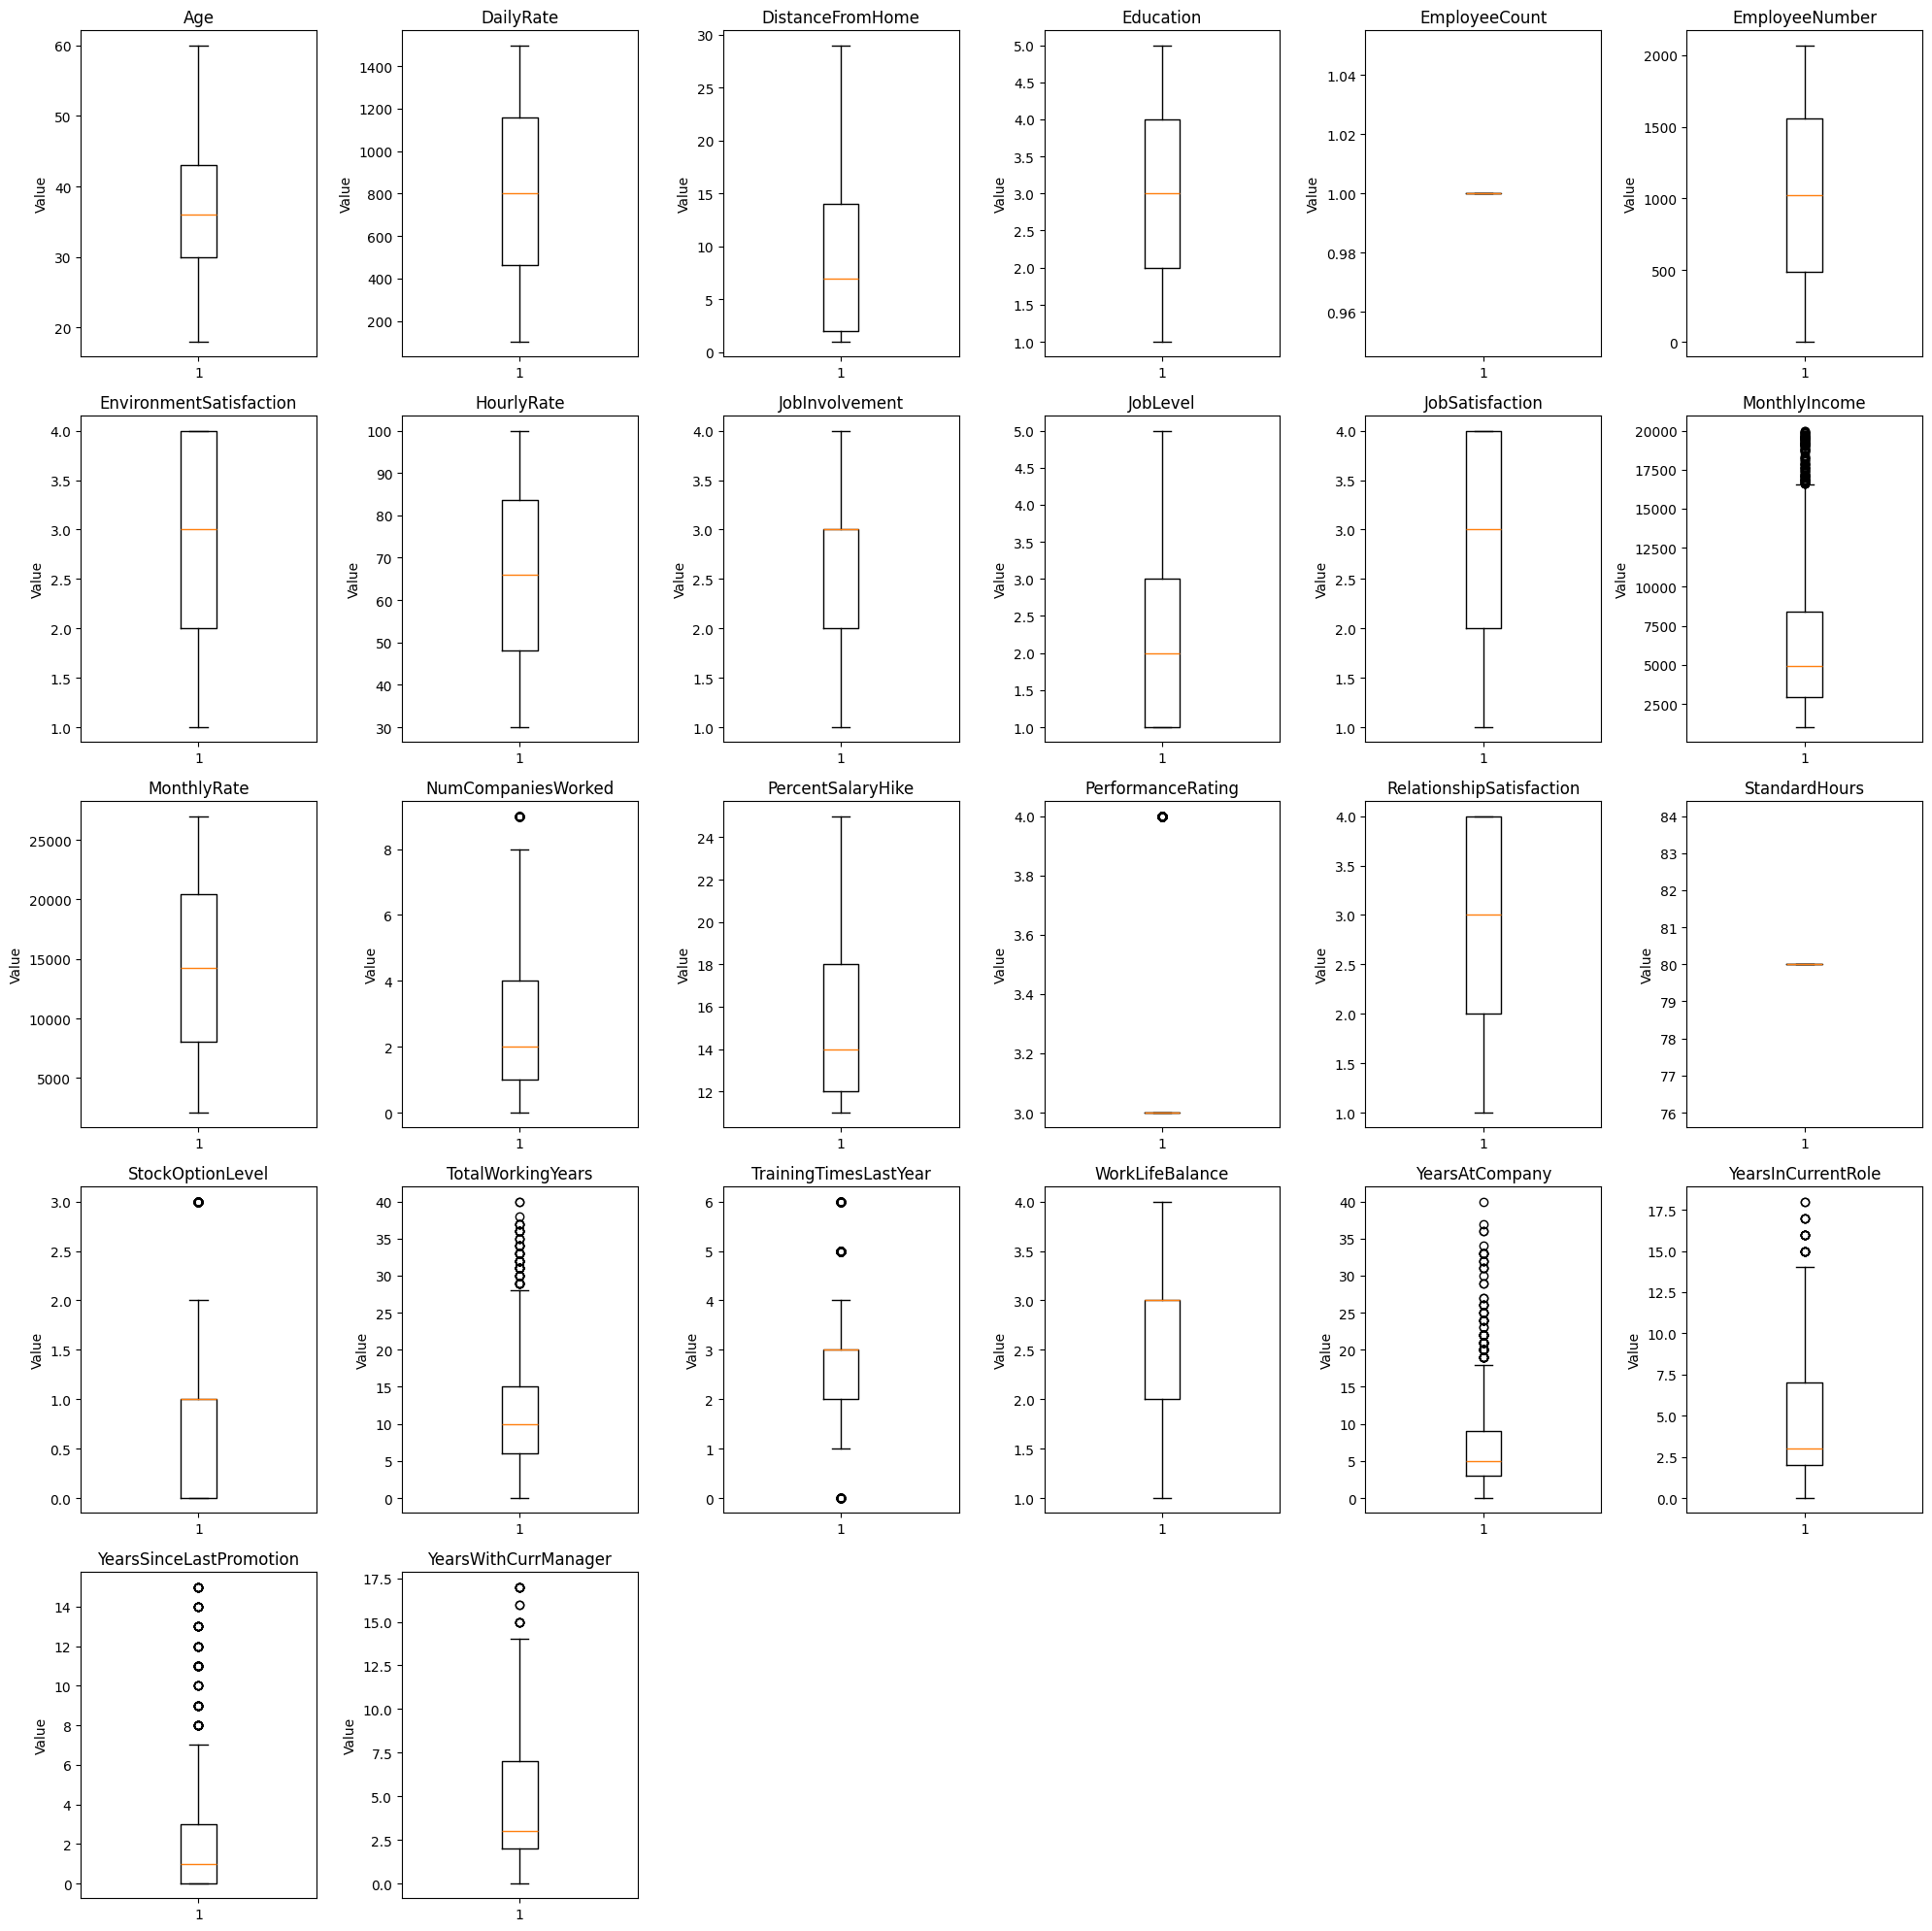

In [58]:
num_cols = len(cont_data.columns)
cols = 6  # number of plots per row (you can adjust)
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(cont_data.columns):
    plt.subplot(rows, cols, i+1)
    plt.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [59]:
def cap_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[column] = np.where(df[column] > upper, upper, df[column])
        df[column] = np.where(df[column] < lower, lower, df[column])
    
    return df

df_clean = cap_outliers(df_clean, ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany'])

In [60]:
cont_data=df_clean.select_dtypes(exclude='object')
cont_data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8.0,0,1,6.0,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10.0,3,3,10.0,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7.0,3,3,0.0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8.0,3,3,8.0,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6.0,3,3,2.0,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17.0,3,3,5.0,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9.0,5,3,7.0,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6.0,0,3,6.0,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17.0,3,2,9.0,6,0,8


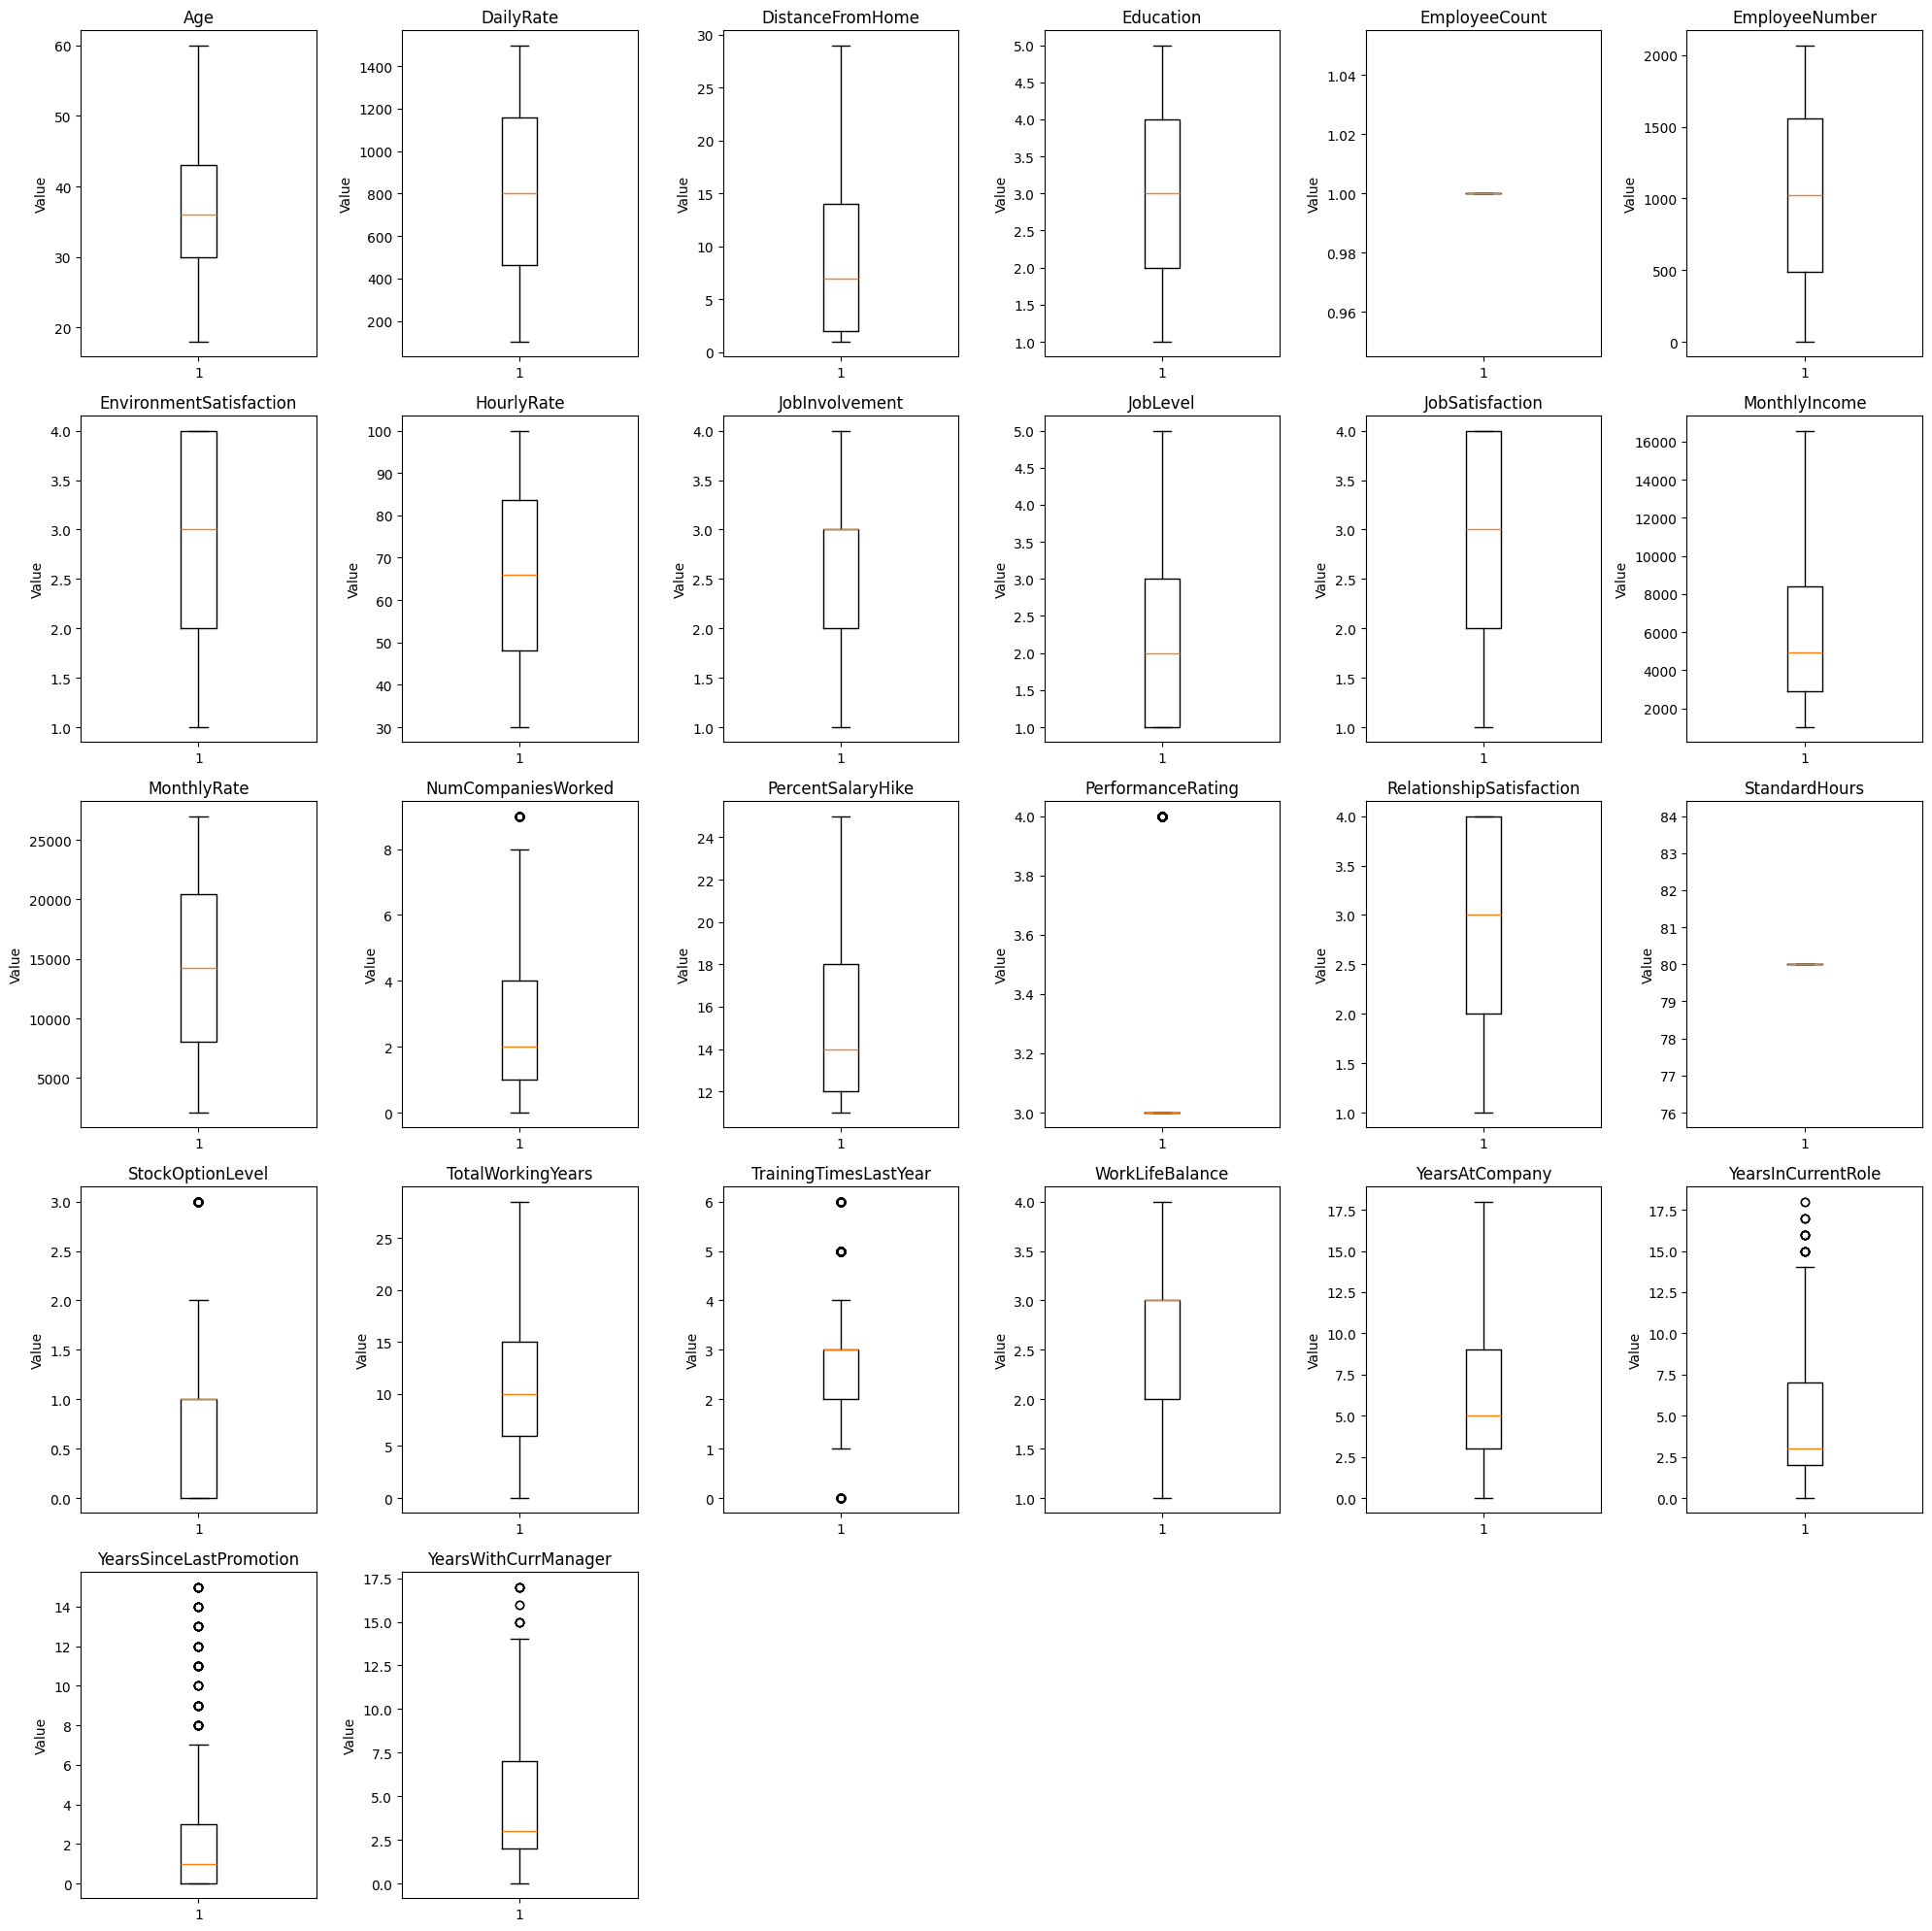

In [61]:
num_cols = len(cont_data.columns)
cols = 6  # number of plots per row (you can adjust)
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(cont_data.columns):
    plt.subplot(rows, cols, i+1)
    plt.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

- Outliers were identified using boxplots and addressed using the Interquartile Range (IQR) method. While extreme outliers were reduced, some values were retained as they represent valid real-world observations, such as employees with high income or extensive work experience.

- Initially, outliers were removed which reduced the dataset size. However, a capping approach was later preferred to preserve important observations while limiting the influence of extreme values.

In [62]:
cat_data = df_clean.select_dtypes(include='object')
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [63]:
# Step 1: Drop useless columns FIRST
df_clean = df_clean.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], errors='ignore')

# Step 2: Encode
le = LabelEncoder()
df_clean['Attrition'] = le.fit_transform(df_clean['Attrition'])
df_clean['OverTime'] = le.fit_transform(df_clean['OverTime'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Step 3: One-hot encode
df_clean = pd.get_dummies(df_clean, drop_first=True)

- Categorical variables were encoded to make them suitable for machine learning models. Binary variables such as Attrition, Gender and OverTime were encoded using Label Encoding. For variables with multiple categories, One-Hot Encoding was applied resulting in the creation of additional binary columns representing each category.


In [64]:
cat_data = df_clean.select_dtypes(include='object')
cat_data

""
0
1
2
3
4
...
1465
1466
1467
1468


In [65]:
df_clean

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,False,True,False,True,False


**b) Univariate Analysis**

(i) DISTRIBUTION OF TARGET VARIABLE (Attrition)

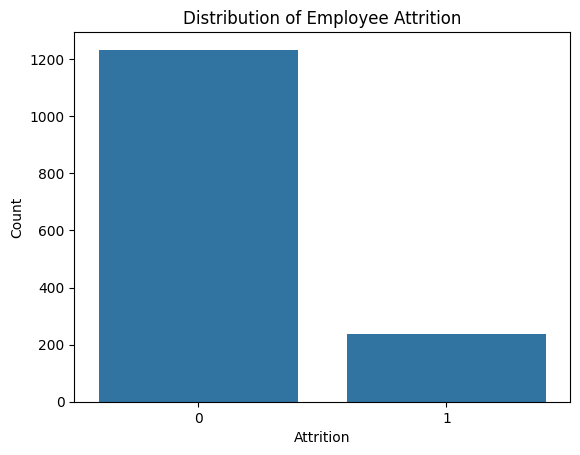

In [66]:
sns.countplot(x='Attrition', data=df_clean)
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

- The distribution of the target variable Attrition shows that the dataset is imbalanced. A significantly larger number of employees did not leave the company (Attrition = 0) compared to those who did (Attrition = 1).

This indicates that the data is skewed toward the majority class (non-attrition). As a result, relying solely on accuracy may be misleading, and additional evaluation metrics such as precision, recall, and F1-score are necessary to properly assess model performance.

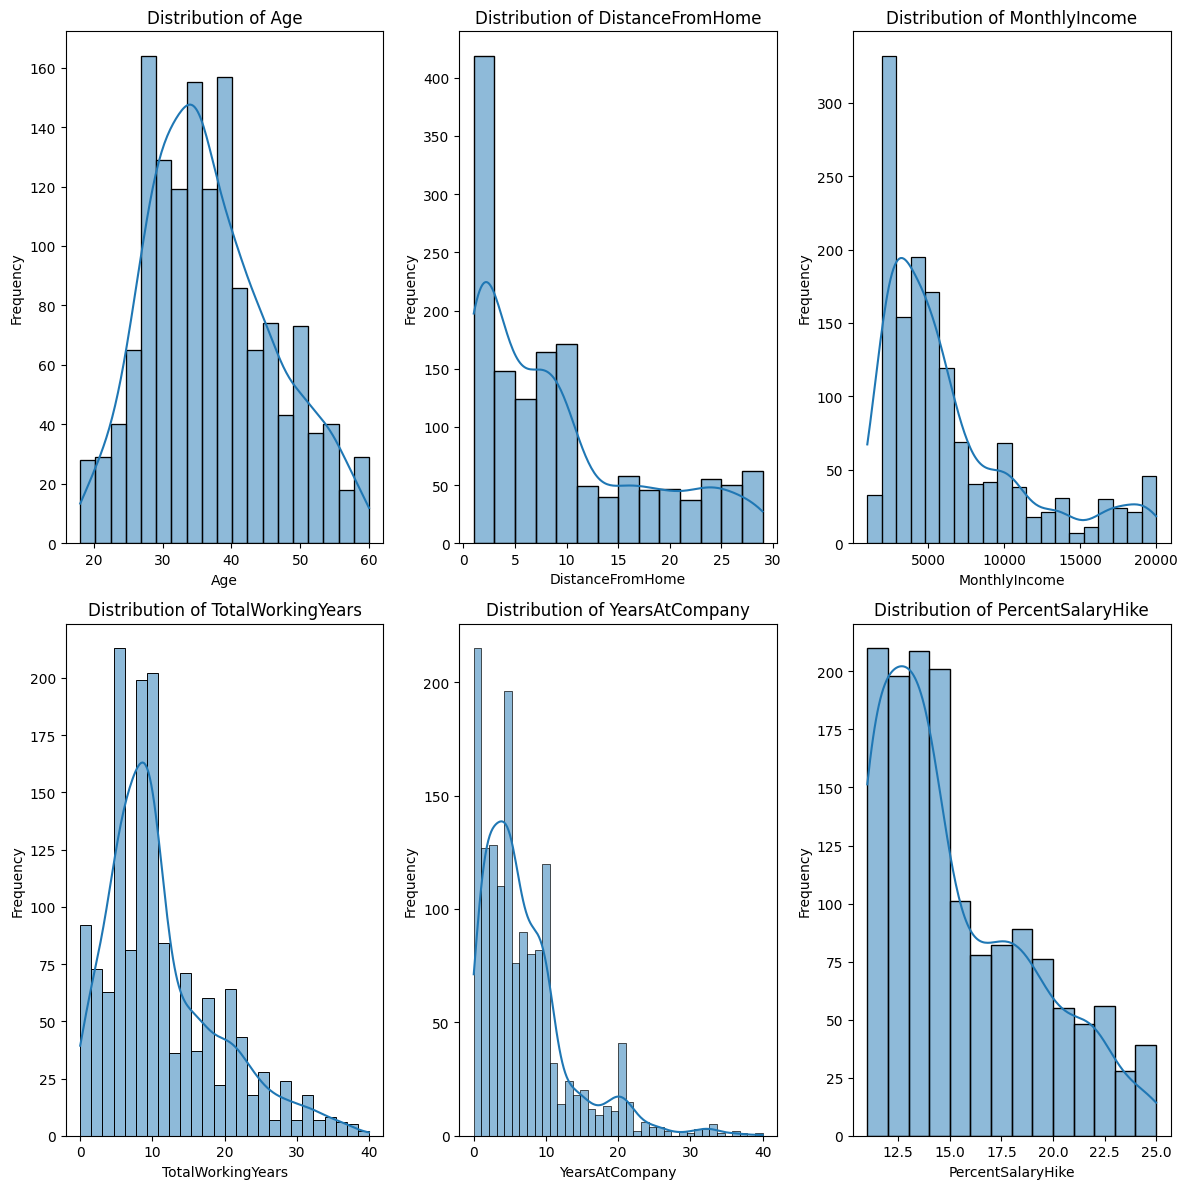

In [67]:
features = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'PercentSalaryHike']

plt.figure(figsize=(12, 12))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The distributions of key numerical features reveal several important patterns:

- Age: The distribution is approximately normal, with most employees falling between 30 and 40 years. This suggests a relatively mature workforce with fewer very young or very old employees.
- DistanceFromHome: The distribution is right-skewed, with most employees living close to the workplace and fewer employees commuting long distances. This indicates that long-distance commuting is less common.
- MonthlyIncome: The distribution is highly right-skewed, with most employees earning lower to moderate salaries and a small number earning significantly higher incomes. This suggests income disparity within the organization.
- TotalWorkingYears: The distribution is right-skewed, indicating that most employees have relatively fewer years of experience, while a smaller number have extensive experience.
- YearsAtCompany: This feature is also right-skewed, showing that many employees have spent fewer years at the company, which may indicate higher turnover among newer employees.
- PercentSalaryHike: The distribution is moderately right-skewed, with most employees receiving smaller salary increases and fewer receiving larger raises.

Overall, most features exhibit right-skewed distributions, suggesting that extreme high values exist but are relatively rare. These patterns support the earlier observation that employee characteristics vary widely and may influence attrition in combination rather than individually.

In [68]:
df_clean

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,False,True,False,True,False


**(c) Bivariate and Multivariate Analysis**

(i) CORRELATION HEATMAP

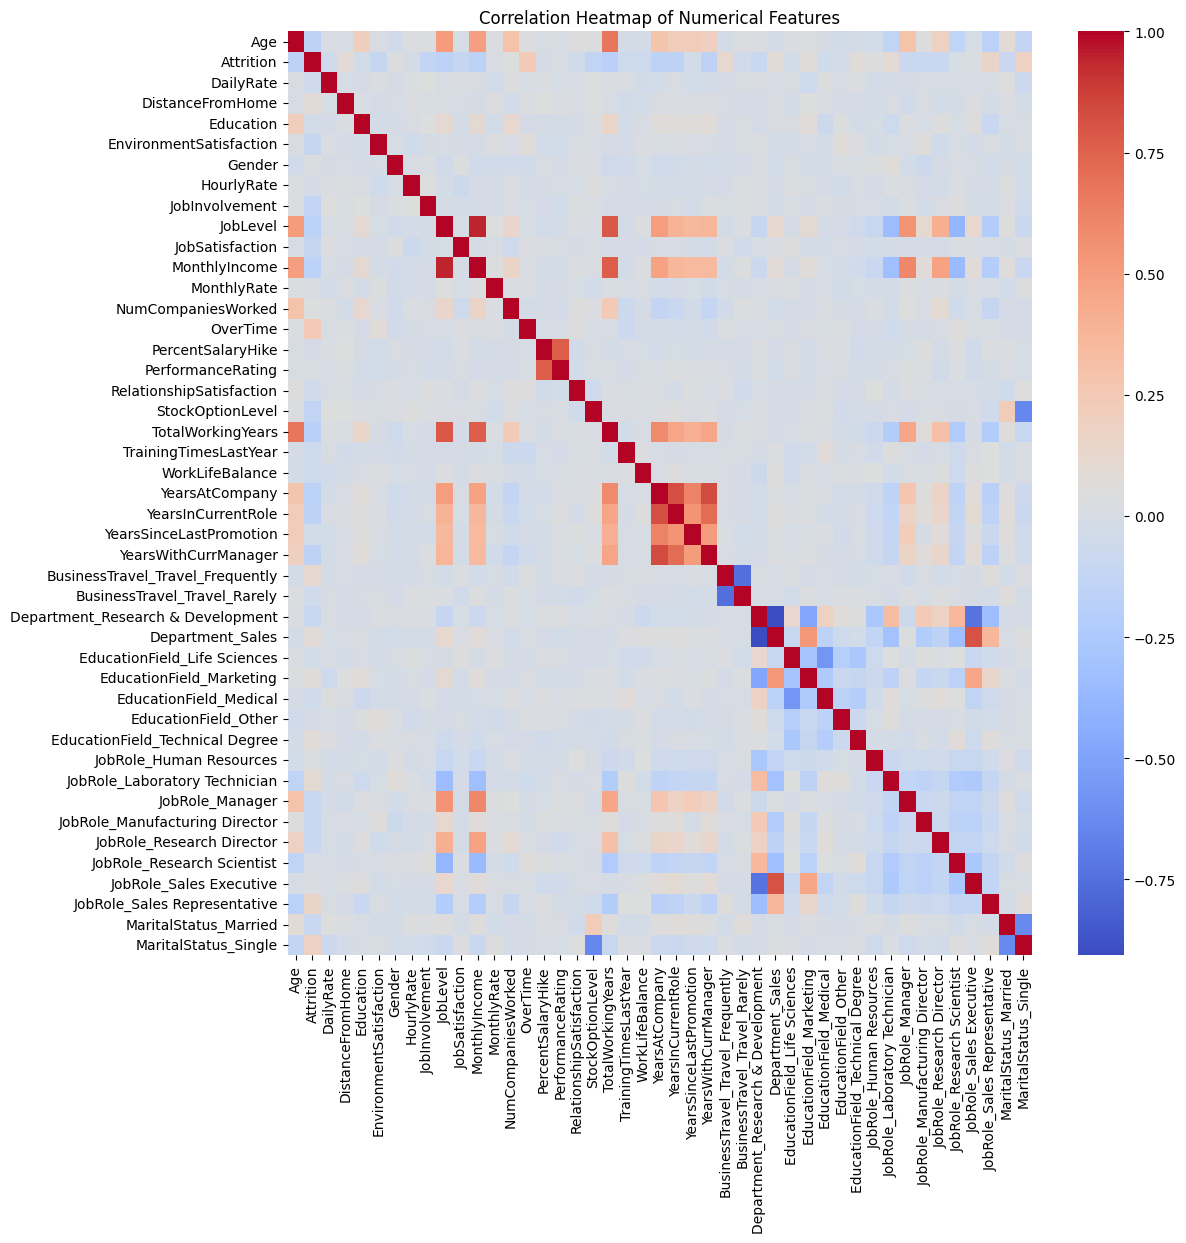

In [69]:
plt.figure(figsize=(12, 12))
corr = df_clean.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Features MOST CORRELATED with Attrition (Target)

- OverTime -> positive correlation. 
    Employees who work overtime are more likely to leave.

- Age -> negative correlation.
    Younger employees are more likely to leave.

- MonthlyIncome -> negative correlation.
    Lower income is associated with higher attrition.

- TotalWorkingYears -> negative correlation.
    Less experienced employees tend to leave more.

- YearsAtCompany -> negative correlation.
    Employees who have stayed longer are less likely to leave.

A correlation heatmap was used to examine relationships between variables. The target variable Attrition shows noticeable relationships with features such as OverTime, Age, MonthlyIncome, TotalWorkingYears and YearsAtCompany. 

- Additionally, strong correlations were observed among experience-related features such as TotalWorkingYears, YearsAtCompany, YearsInCurrentRole and YearsWithCurrManager indicating potential multicollinearity. 
- A strong relationship was also observed between JobLevel and MonthlyIncome as well as between PerformanceRating and PercentSalaryHike.

Overall, the correlations suggest that employee attrition is influenced by multiple factors rather than a single dominant variable.

ii) Grouped Visualizations

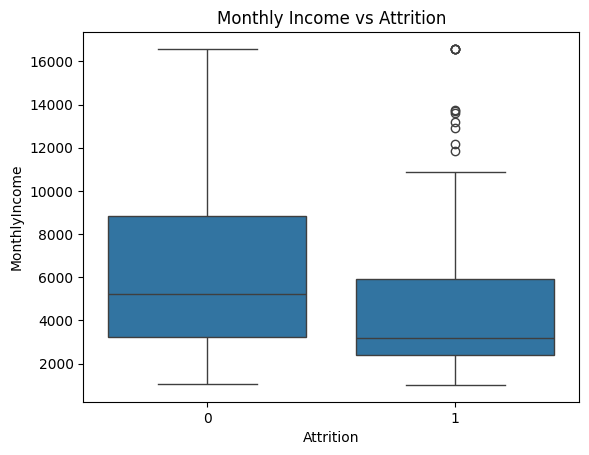

In [70]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean)
plt.title("Monthly Income vs Attrition")
plt.show()

- The boxplot indicates that employees who left the company generally have lower monthly incomes compared to those who stayed but there are some outliers who recieved high income but left.

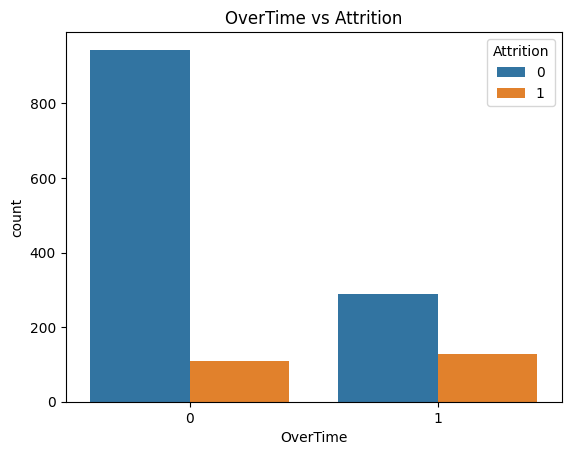

In [71]:
sns.countplot(x='OverTime', hue='Attrition', data=df_clean)
plt.title("OverTime vs Attrition")
plt.show()

The plot above shows that employees who work overtime are less likely to leave the company compared to those who do not. This suggests that excessive workload may not be a major factor contributing to employee attrition.

iii) Pairplot

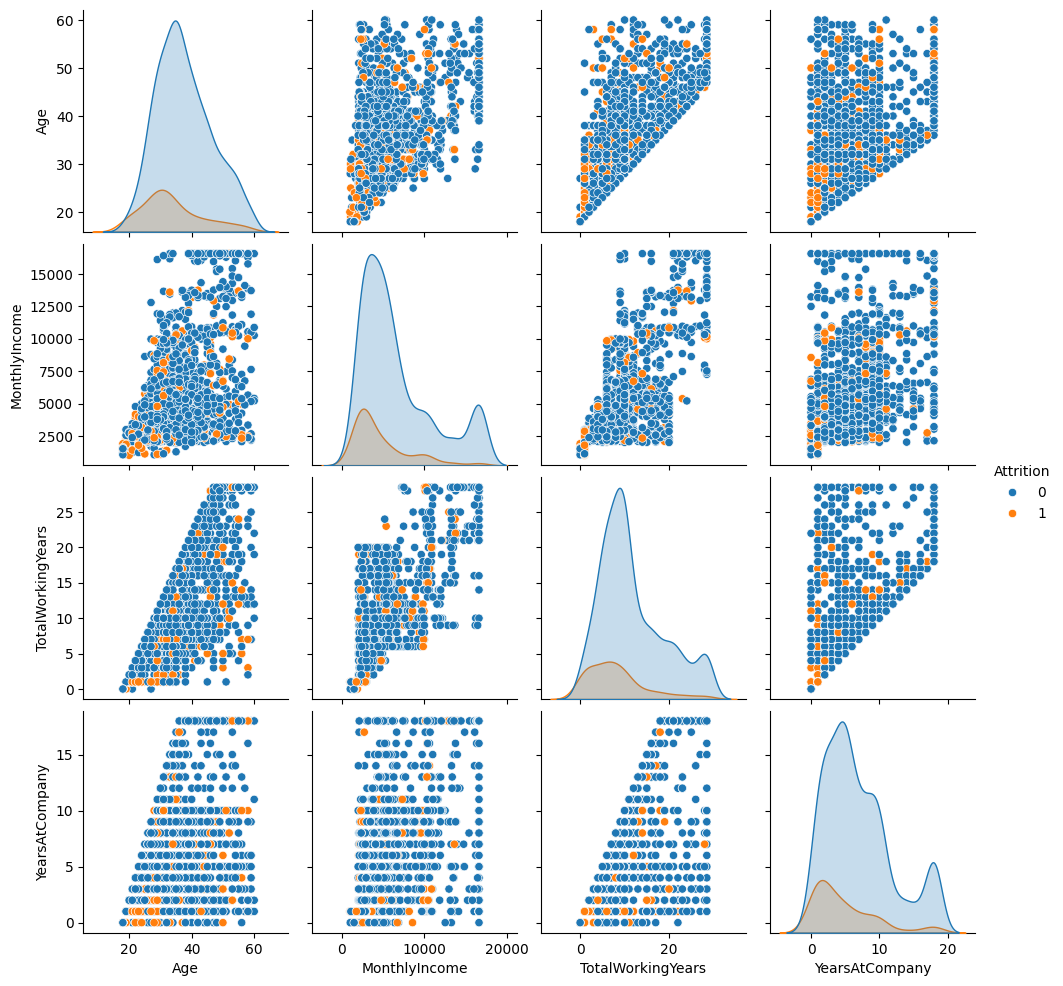

In [72]:
selected_features = [
    'Age', 
    'MonthlyIncome', 
    'TotalWorkingYears', 
    'YearsAtCompany', 
    'Attrition'
]

sns.pairplot(df_clean[selected_features], hue='Attrition')
plt.show()

The pairplot provides a multivariate view of the dataset by visualizing relationships between multiple features simultaneously. While individual features show weak correlations with attrition, the pairplot reveals patterns where combinations of factors such as low income and fewer years of experience are associated with higher attrition. This supports the conclusion that employee attrition is influenced by multiple interacting variables rather than a single dominant factor.

**(d) Key Insights**

- The target variable *Attrition* is imbalanced, with significantly more employees staying than leaving. This indicates that evaluation metrics beyond accuracy, such as precision, recall and F1-score are necessary.

- No single feature shows a strong linear correlation with attrition, suggesting that employee turnover is influenced by multiple interacting factors rather than a single dominant variable.

- Employees working overtime exhibit a higher proportion of attrition compared to those who do not. Although the absolute number of non-overtime employees is larger, the likelihood of leaving is slightly higher among employees who work overtime.

- Features such as MonthlyIncome, TotalWorkingYears and YearsAtCompany indicate that employees with lower income and less experience tend to have higher attrition rates.

- Strong correlations exist among experience-related features (e.g. TotalWorkingYears, YearsAtCompany, YearsInCurrentRole) indicating potential multicollinearity that may affect some models.

- Outliers were identified in features such as MonthlyIncome and TotalWorkingYears. These were handled carefully to reduce their impact while preserving meaningful real-world values.

- Based on our EDA, Overtime and Monthly Income could be the most important features to our model. 

### Section C

**(a) Data Preparation**

a) i)

In [73]:
# Target variable
y = df_clean['Attrition']

# Feature matrix (drop target)
X = df_clean.drop(columns=['Attrition'])    

ii)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

iii)

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to standardize numerical features. This ensures that all features have a mean of 0 and a standard deviation of 1.

Scaling is particularly important for algorithms such as Logistic Regression, which are sensitive to the magnitude of input features. However, tree-based models such as Random Forest do not require feature scaling, as they are not affected by feature scale.

Therefore, scaling was applied to support models that rely on distance or gradient-based optimization.

MODEL 1: RANDOM FOREST REGRESSOR

The primary model selected for this project is the Random Forest Classifier, a supervised machine learning algorithm used for classification tasks.

Random Forest was chosen because it is an ensemble method that combines multiple decision trees to improve predictive accuracy and reduce overfitting. It is particularly suitable for this dataset as it can handle both numerical and categorical features effectively and capture complex, non-linear relationships between variables.

Additionally, Random Forest is robust to outliers and does not require feature scaling, making it well-suited for the employee attrition dataset.

In [76]:
# Base model
rf = RandomForestClassifier(random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8741496598639455


- Hyperparameter tuning

In [77]:
results = []

configs = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 300, 'max_depth': 5}
]

for config in configs:
    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((config, acc))

# Print results
for config, acc in results:
    print(config, " Accuracy:", acc)



results_df = pd.DataFrame(results, columns=['Configuration', 'Accuracy'])
results_df

{'n_estimators': 100, 'max_depth': None}  Accuracy: 0.8741496598639455
{'n_estimators': 200, 'max_depth': 10}  Accuracy: 0.8775510204081632
{'n_estimators': 300, 'max_depth': 5}  Accuracy: 0.8775510204081632


,Configuration,Accuracy
0,"{'n_estimators': 100, 'max_depth': None}",0.874150
1,"{'n_estimators': 200, 'max_depth': 10}",0.877551
2,"{'n_estimators': 300, 'max_depth': 5}",0.877551


Hyperparameter tuning was performed by testing multiple configurations of the Random Forest model. The number of trees (n_estimators) and the maximum depth of each tree (max_depth) were varied to evaluate their impact on model performance.

The results show that different configurations produce slightly different accuracy scores, allowing selection of the best-performing model.


The following hyperparameters were tuned in the Random Forest model:

- n_estimators: This parameter controls the number of decision trees in the forest. Increasing the number of trees generally improves model performance by reducing variance, but it also increases computational cost.
- max_depth: This parameter determines the maximum depth of each decision tree. A deeper tree can capture more complex patterns but may lead to overfitting, while a shallow tree may underfit the data.

By experimenting with different values of these hyperparameters, the model was optimized to achieve a balance between bias and variance.

MODEL 2: Logistic Regression

In [78]:
# Base model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

Accuracy: 0.8809523809523809


In [79]:
results_lr = []

configs_lr = [
    {'C': 1.0, 'solver': 'lbfgs'},
    {'C': 0.1, 'solver': 'liblinear'}
]

for config in configs_lr:
    model = LogisticRegression(
        C=config['C'],
        solver=config['solver'],
        max_iter=1000,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    results_lr.append((config, acc))

# Print results
for config, acc in results_lr:
    print(config, "→ Accuracy:", acc)


results_lr_df = pd.DataFrame(results_lr, columns=['Configuration', 'Accuracy'])
results_lr_df

{'C': 1.0, 'solver': 'lbfgs'} → Accuracy: 0.8809523809523809
{'C': 0.1, 'solver': 'liblinear'} → Accuracy: 0.8945578231292517


,Configuration,Accuracy
0,"{'C': 1.0, 'solver': 'lbfgs'}",0.880952
1,"{'C': 0.1, 'solver': 'liblinear'}",0.894558


The following hyperparameters were tuned for the Logistic Regression model:

C (Regularization Strength): This parameter controls the strength of regularization. A smaller value of C increases regularization, which helps prevent overfitting but may reduce model flexibility. A larger value allows the model to fit the training data more closely.
Solver: This parameter determines the optimization algorithm used to train the model. Different solvers are suitable for different dataset sizes and types. For example, lbfgs is efficient for larger datasets, while liblinear is suitable for smaller datasets and binary classification.

By testing different configurations, the model’s performance was evaluated and compared against the Random Forest model.

RANDOM FOREST EVALUATION

In [80]:
# Best RF model (replace with your best config if different)
rf_best = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_best.fit(X_train, y_train)

y_pred_rf = rf_best.predict(X_test)

# Classification report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



LOGISTIC REGRESSION EVALUATION

In [81]:
# Best LR model
lr_best = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_best.fit(X_train_scaled, y_train)

y_pred_lr = lr_best.predict(X_test_scaled)

# Classification report
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.57      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.74      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294



Confusion Matrix

C:\Users\YOGA\AppData\Local\Temp\ipykernel_14880\2185199539.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Count', loc='upper left')


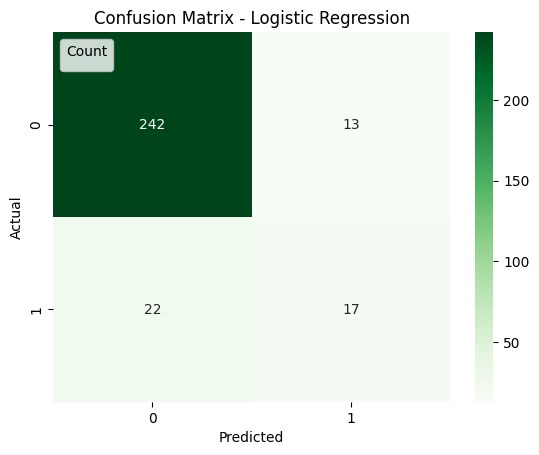

In [82]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.legend(title='Count', loc='upper left')
plt.show()

The Logistic Regression model was evaluated using the same classification metrics. The confusion matrix shows that while the model performs well in predicting employees who stayed, it is slightly less effective in identifying employees who left compared to the Random Forest model.

The classification report shows slightly lower recall for the minority class, indicating that the model may struggle with class imbalance.

In [83]:
# Random Forest metrics
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

# Logistic Regression metrics
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
}

comparison_df = pd.DataFrame([rf_metrics, lr_metrics])
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.877551,0.800000,0.102564,0.181818
1,Logistic Regression,0.880952,0.566667,0.435897,0.492754


There are several trade-offs between the two models:

Random Forest:
Pros: Handles complex relationships, higher predictive performance, robust to outliers
Cons: Less interpretable, higher computational cost
Logistic Regression:
Pros: Simple, interpretable, computationally efficient
Cons: Assumes linear relationships, lower performance on complex datasets

Overall, while Logistic Regression provides interpretability, Random Forest offers better predictive accuracy for this multi-factor problem.

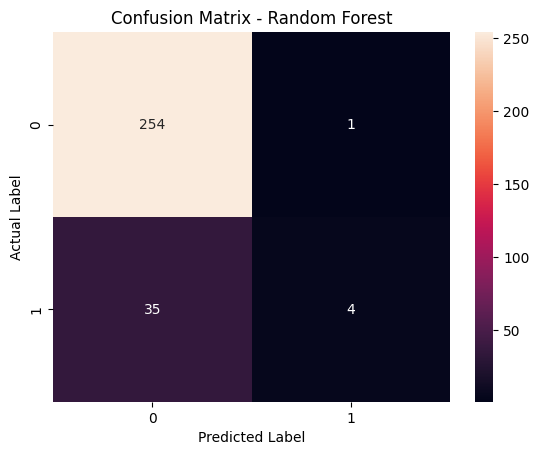

In [84]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

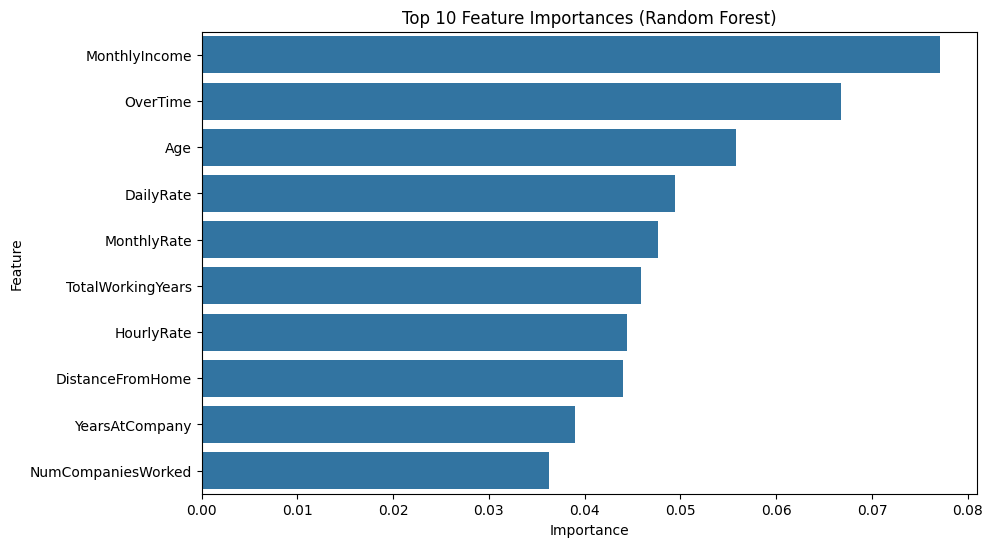

In [85]:
importances = rf_best.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows the most influential variables in predicting employee attrition. Features such as MonthlyIncome, OverTime and Age appear among the most important predictors, confirming insights obtained during exploratory data analysis.

This further supports the conclusion that employee attrition is influenced by multiple interacting factors.